<a href="https://colab.research.google.com/github/timur262007/first-project/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%B2_%D1%80%D0%B0%D0%BC%D0%BA%D0%B0%D1%85_%D0%9C%D0%B0%D0%B3%D0%B8%D1%81%D1%82%D1%80%D0%B0%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%98%D0%A3_%D0%92%D0%A8%D0%AD_%22%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%91%D0%BE%D0%BB%D1%8C%D1%88%D0%B8%D1%85_%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D1%85%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA в два клика!

# Titanic Dataset

В первой части ноутбука мы проведём полный разведочный анализ данных о пассажирах Титаника:
- Общая структура данных
- Анализ пропущенных значений
- Анализ числовых и категориальных признаков
- Корреляции и зависимости
- Визуализации: распределения, скрипичные диаграммы, тепловая карта
- Предварительные гипотезы

## 1. Импорт библиотек и загрузка данных

In [ ]:
# Одно из двух
#! conda install ydata-profiling --y
! pip install ydata-profiling


In [ ]:
# Одно из двух
#! conda install sweetviz --y
! pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 36.1 MB/s eta 0:00:00


In [ ]:
# Одно из двух
#! conda install dtale --y
! pip install dtale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 37.2 MB/s eta 0:00:00
  Created wheel for dash_daq: filename=dash_daq-0.5.0-py3-none-any.whl size=669693 sha2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Расширенные библиотеки
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import folium

# AutoEDA
from ydata_profiling import ProfileReport
import sweetviz as sv
import dtale

# Для отображения
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Общая информация и структура

In [ ]:
titanic.info()
titanic.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Пропущенные значения

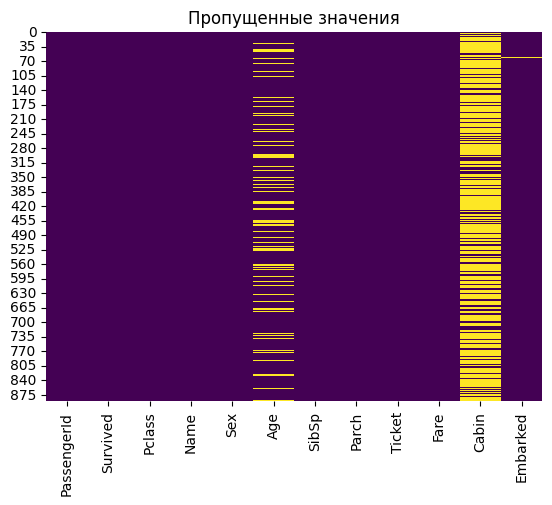

In [ ]:

sns.heatmap(titanic.isnull(), cbar=False, cmap="viridis")
plt.title("Пропущенные значения")
plt.show()


## 4. Пол и выживаемость

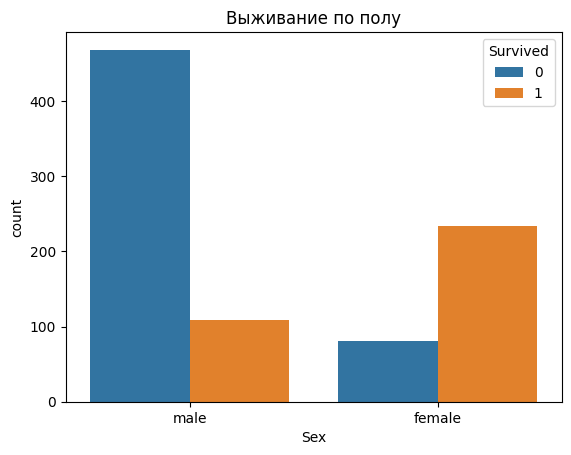

In [ ]:
sns.countplot(data=titanic, x="Sex", hue="Survived")
plt.title("Выживание по полу")
plt.show()



In [ ]:
pd.crosstab(titanic["Sex"], titanic["Survived"], normalize='index') * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


## 5. Класс каюты и выживаемость

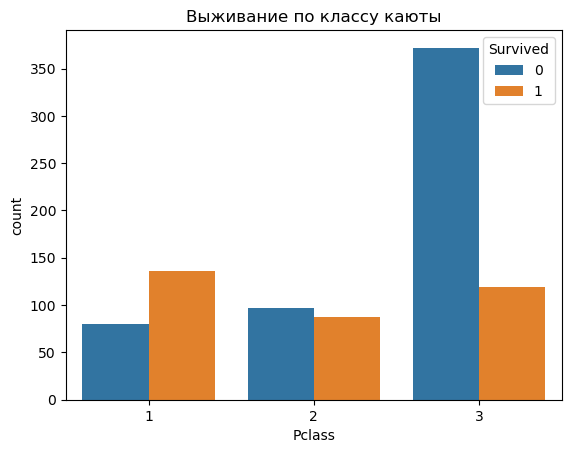

In [ ]:
sns.countplot(data=titanic, x="Pclass", hue="Survived")
plt.title("Выживание по классу каюты")
plt.show()

## 6. Возраст: распределение и выживание

In [ ]:
sns.histplot(data=titanic, x="Age", bins=30, kde=false)
plt.title("Распределение возраста")
plt.show()

NameError: name 'sns' is not defined

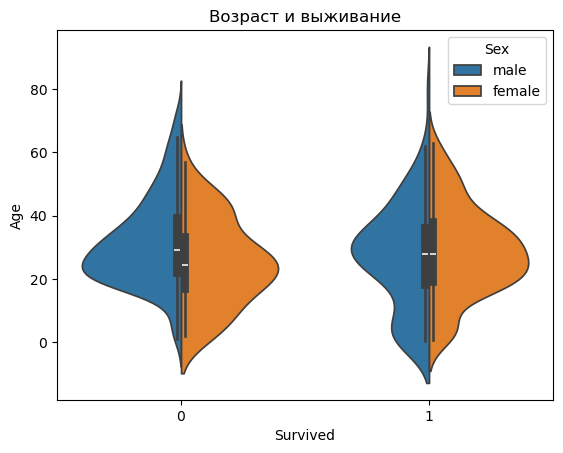

In [ ]:
sns.violinplot(data=titanic, x="Survived", y="Age", hue="Sex", split=True)
plt.title("Возраст и выживание")
plt.show()

## 7. Семьи на борту

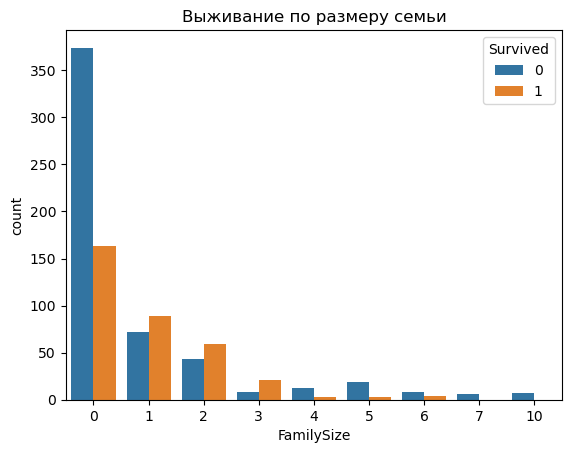

In [ ]:
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"]
sns.countplot(data=titanic, x="FamilySize", hue="Survived")
plt.title("Выживание по размеру семьи")
plt.show()

## 8. Стоимость билета

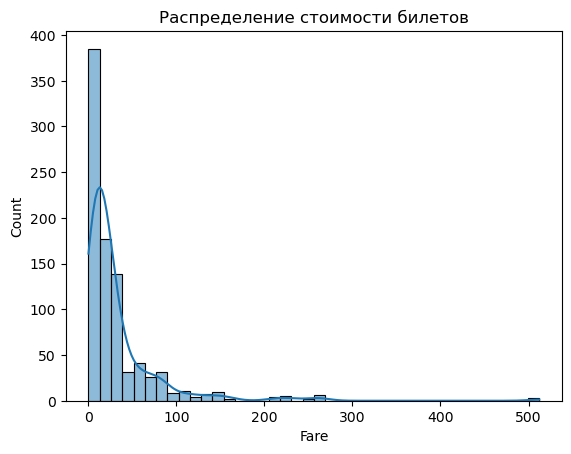

In [ ]:
sns.histplot(titanic["Fare"], bins=40, kde=True)
plt.title("Распределение стоимости билетов")
plt.show()

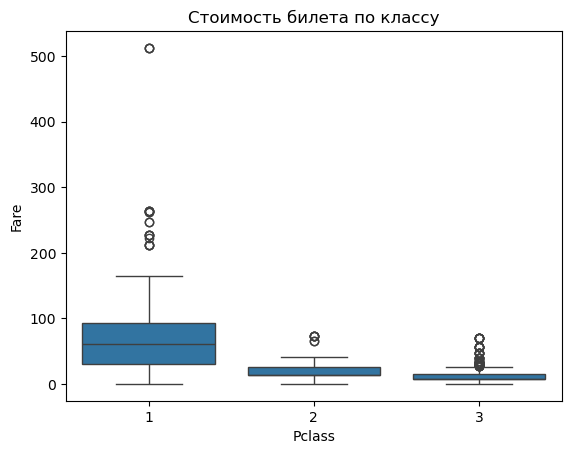

In [ ]:
sns.boxplot(data=titanic, x="Pclass", y="Fare")
plt.title("Стоимость билета по классу")
plt.show()


## 9. Корреляции и тепловая карта

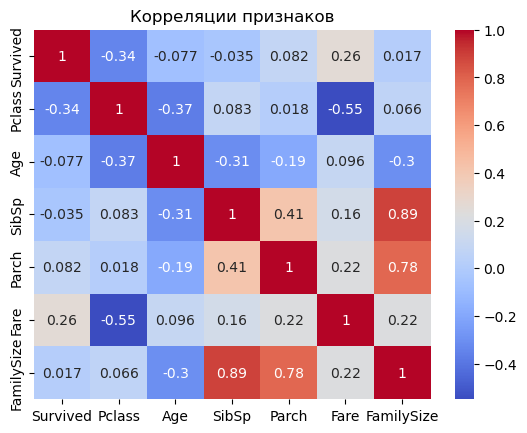

In [ ]:
corr = titanic[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляции признаков")
plt.show()

## 10. Порт посадки

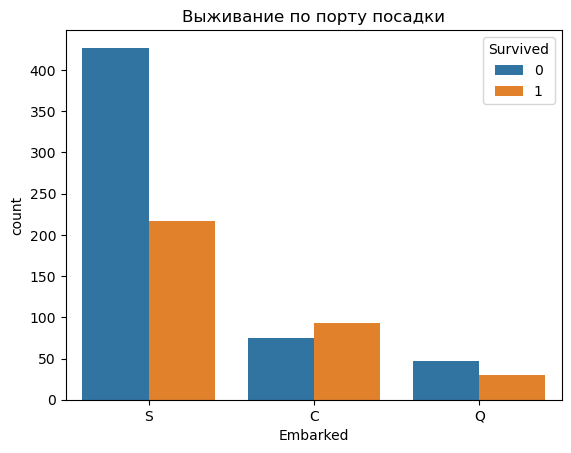

In [ ]:
sns.countplot(data=titanic, x="Embarked", hue="Survived")
plt.title("Выживание по порту посадки")
plt.show()

## 11. Интерактив: возраст и стоимость билета

In [ ]:
fig = px.scatter(titanic, x="Age", y="Fare", color="Survived", hover_data=["Sex", "Pclass"])
fig.update_layout(title="Возраст vs Цена билета (цвет = выживание)")
fig.show()


## 12. Выводы

- Женщины и пассажиры 1 класса выживали чаще.
- Большие семьи реже выживали.
- Чем выше цена билета — тем выше шанс на выживание.
- Возраст также влиял: дети выживали чаще.

EDA показывает важные признаки, влияющие на выживание, и может быть использован для обучения моделей машинного обучения.

## 13. AutoEDA: YData Profiling и Sweetviz

In [ ]:
# YData Profiling
profile = ProfileReport(titanic, title="Titanic Report", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████| 13/13 [00:00<00:00, 10270.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Sweetviz
report = sv.analyze(titanic)
report.show_html("sweetviz_titanic.html")

                                             |      | [  0%]   00:00 -> (? left)

Report sweetviz_titanic.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


0:100: execution error: Файл некий объект не найден. (-43)


In [ ]:
# D-Tale запуск (в ноутбуке не интерактивно, но можно открыть как веб)
dtale.show(titanic)

# Bonus Part

## Датасет 2: Airbnb NYC + Гео-визуализация

In [ ]:
airbnb = pd.read_csv("Airbnb_Open_Data.csv")

# Приведём цену к числовому формату, если нужно
airbnb = airbnb[airbnb["price"] < "$500"]  # фильтрация выбросов
airbnb = airbnb.dropna(subset=["lat", "long"])

airbnb[["NAME", "neighbourhood group", "lat", "long", "price"]].sample(5)


,NAME,neighbourhood group,lat,long,price
81539,Upper west side - perfect feel at home place.,Manhattan,40.78526,-73.97633,"$1,092"
63181,Beautiful apartment 1 bedroom at Brooklyn,Brooklyn,40.58185,-73.96412,$412
23035,A Home Base in Brooklyn,Brooklyn,40.70545,-73.94714,$315
88899,Best part of Brooklyn! Large room in Bushwick.,Brooklyn,40.70342,-73.92829,$344
96364,Flatiron Oasis Off 5th Ave,Manhattan,40.74043,-73.99277,$348


In [ ]:
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
for _, row in airbnb.sample(200).iterrows():
    folium.CircleMarker([row["lat"], row["long"]], radius=3,
                        popup=f"{row['price']}", color="blue").add_to(m)
m

## Датасет 3: World Happiness Report (Геокарта + тепловая карта)

In [ ]:

happiness = pd.read_csv("world_happiness_combined.csv", delimiter=';')

# Берём последний год (2023 или 2024)
last_year = happiness["Year"].max()
h = happiness[happiness["Year"] == last_year]

fig = px.choropleth(
    h,
    locations="Country",
    locationmode="country names",
    color="Healthy life expectancy",
    hover_name="Country",
    title=f"World Happiness ({last_year})"
)
fig.show()


## Экспорт в HTML

In [ ]:
# Пример сохранения HTML-страницы с графиком
fig.write_html("happiness_map.html")

2025-06-19 22:49:04,025 - INFO     - Executing shutdown due to inactivity...
2025-06-19 22:49:04,212 - INFO     - Executing shutdown...
2025-06-19 22:49:04,213 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer
2025-06-19 22:49:04,358 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,359 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,360 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,361 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,362 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,364 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,364 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,365 - ERROR    - weakly-referenced object no longer exists
2025-06-19 22:49:04,366 - ERROR    - weakly-referenced object no longer exists


# Заключение

EDA можно делать как вручную, так и в пару кликов:
- Для гибкости — используем pandas/seaborn
- Для скорости — AutoEDA инструменты
- Для WOW-эффекта — интерактивы, карты, HTML

Спасибо за внимание!